In [22]:
import torch
import matplotlib.pyplot as plt
import math
import scipy.io
import numpy as np
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [23]:
# ─── Parameters ────────────────────────────────────────────────
dt = 1e-2             # Time step
num_steps = 200           # Total steps
T = num_steps * dt          # Total time
num_particles = 1*10**6       # Reduced for performance
small_region_radius = 0.13  # Increased radius

mat = scipy.io.loadmat('data/initialData.mat')['initialData']
small_region_centers = torch.from_numpy(mat).to(device=device, dtype=torch.float32)

In [24]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
std0 = math.sqrt(1.0)
weightsX0 = torch.tensor([1.0], device=device)
mu_X0 = torch.tensor([[0.,0.]], device=device)
covariances_X0 = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([0.0], device=device)
mu_Xinf = torch.tensor([[0.,0.]], device=device)
inv_covariances_T = torch.zeros_like(torch.eye(2, device=device).unsqueeze(0))
det_T = 0.0

In [25]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [26]:
boolMask = np.empty(small_region_centers.shape[0], dtype=bool)

# Check if there are particles inside the small regions 
for center in range(small_region_centers.shape[0]):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks = distances < small_region_radius
    num_selected = masks.sum().item()
    boolMask[center] = num_selected > 10
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
positions1 = positions.clone()
small_region_centers1 = small_region_centers[boolMask].clone()
initial_positions = positions1.clone().cpu().numpy()
positions2 = positions.clone()
small_region_centers2 = small_region_centers[boolMask].clone()

Number of particles in small region: 138
Number of particles in small region: 1076
Number of particles in small region: 1273
Number of particles in small region: 440
Number of particles in small region: 2844
Number of particles in small region: 3408
Number of particles in small region: 714
Number of particles in small region: 2712
Number of particles in small region: 5038
Number of particles in small region: 5384
Number of particles in small region: 4101
Number of particles in small region: 2935
Number of particles in small region: 5219
Number of particles in small region: 5401
Number of particles in small region: 3487
Number of particles in small region: 5121
Number of particles in small region: 7295
Number of particles in small region: 7432
Number of particles in small region: 4592
Number of particles in small region: 1084
Number of particles in small region: 7569
Number of particles in small region: 7393
Number of particles in small region: 1738
Number of particles in small region: 

In [27]:
simParams1 = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 1, False, small_region_radius, 'AngeloScore', Xinf=False, variableRadius=False)
simParams2 = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 1, False, small_region_radius, 'AngeloScore', Xinf=False, variableRadius=True)

In [28]:
final_positions1, avg_paths1, particlesPerCircle1 = doSimulation(positions1, small_region_centers1, simParams1, device)

Angelo's algorithm is running...
t = 0.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 0.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000


In [29]:
final_positions2, avg_paths2, particlesPerCircle2 = doSimulation(positions2, small_region_centers2, simParams2, device)


Angelo's algorithm is running...
t = 0.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 0.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000


In [30]:
scipy.io.savemat("data/gaussianDiffusionDataAdaptive.mat", {"avg_paths": avg_paths2, "final_positions": final_positions2, "initial_positions": initial_positions, "particlesPerCircle": particlesPerCircle2})

In [31]:
scipy.io.savemat("data/gaussianDiffusionData.mat", {"avg_paths": avg_paths1, "final_positions": final_positions1, "initial_positions": initial_positions, "particlesPerCircle": particlesPerCircle1})


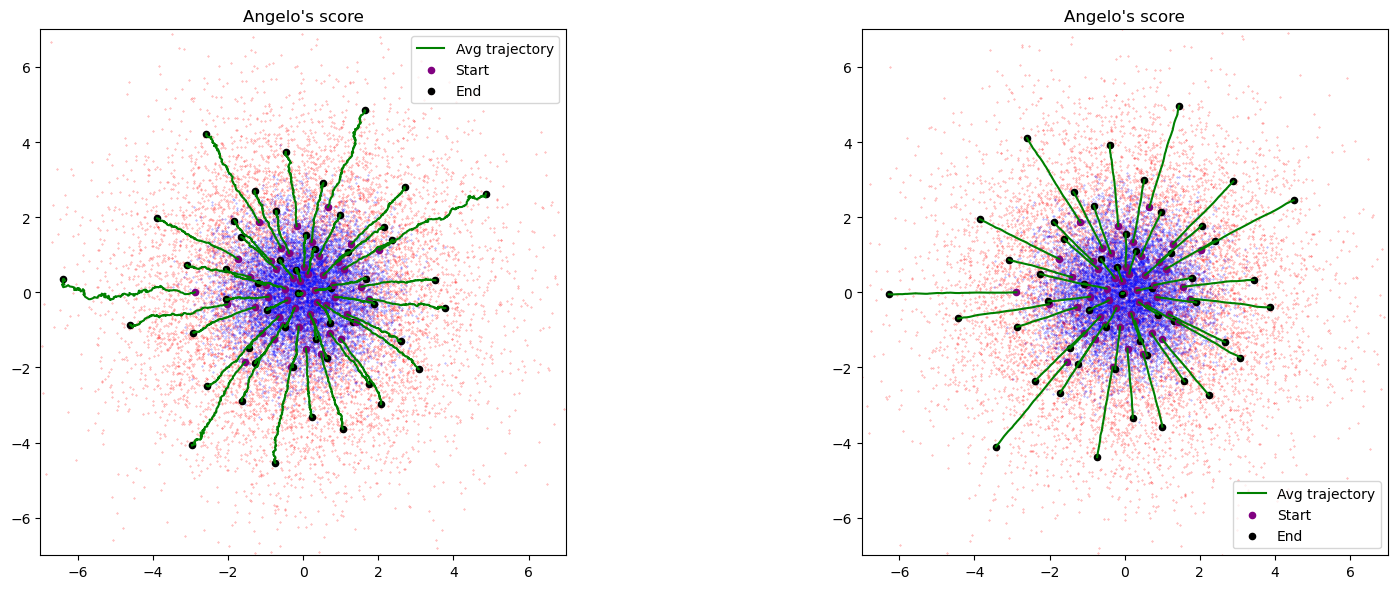

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))


# Trajectory
axes[0].scatter(final_positions1[:10000,0], final_positions1[:10000,1], s=0.1, alpha=0.5, color='red')
axes[0].scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers1.shape[0]):
    axes[0].plot(avg_paths1[:, center, 0], avg_paths1[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[0].scatter(avg_paths1[0, center, 0], avg_paths1[0, center, 1], color='purple', s=20, label='Start'  if center == 0 else None)
    axes[0].scatter(avg_paths1[-1, center, 0], avg_paths1[-1, center, 1], color='black', s=20, label='End'  if center == 0 else None)
axes[0].set_title("Angelo's score")
axes[0].legend()
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlim(-7., 7.)
axes[0].set_ylim(-7., 7.)

axes[1].scatter(final_positions2[:10000,0], final_positions2[:10000,1], s=0.1, alpha=0.5, color='red')
axes[1].scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers1.shape[0]):
    axes[1].plot(avg_paths2[:, center, 0], avg_paths2[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[1].scatter(avg_paths2[0, center, 0], avg_paths2[0, center, 1], color='purple', s=20, label='Start'  if center == 0 else None)
    axes[1].scatter(avg_paths2[-1, center, 0], avg_paths2[-1, center, 1], color='black', s=20, label='End'  if center == 0 else None)
axes[1].set_title("Angelo's score")
axes[1].legend()
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(-7., 7.)
axes[1].set_ylim(-7., 7.)


plt.savefig("GaussianDiffusion.pdf")
plt.tight_layout()
plt.show()

In [33]:
particlesPerCircleNormalized1 = particlesPerCircle1 / particlesPerCircle1[0, :]

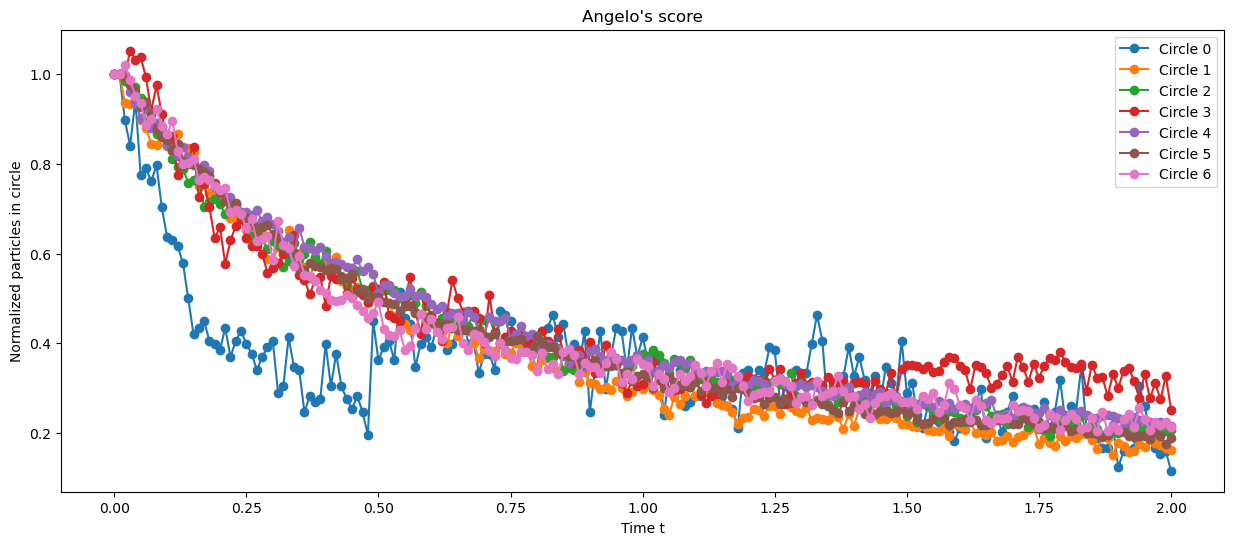

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

timeRange = np.arange(num_steps+1) * dt

# Trajectory
axes.plot(timeRange, particlesPerCircleNormalized1[:, 0], 'o-', label='Circle 0')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 1], 'o-', label='Circle 1')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 2], 'o-', label='Circle 2')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 3], 'o-', label='Circle 3')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 4], 'o-', label='Circle 4')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 5], 'o-', label='Circle 5')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 6], 'o-', label='Circle 6')
axes.legend()
axes.set_xlabel('Time t')
axes.set_ylabel('Normalized particles in circle')
axes.set_title("Angelo's score")

plt.show()
